In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from skbio.stats.composition import ilr, sbp_basis
import torch
from IPython.display import display

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# For reproducibility
np.random.seed(42)

### Setup and Data Preparation

In [ ]:
df_post = pd.read_pickle("../data/oon/df_post_oon.pkl")
df_reg = df_post[['emotion__anger', 'emotion__fear', 'emotion__sadness', 'emotion__disgust', 'emotion__surprise']]

Prepare for ILR Transformation

In [5]:
# Define the persona columns
persona_prob_cols = [f'persona_{i}_prob' for i in range(6)]
persona_matrix = df_reg[persona_prob_cols].values

In [6]:
sbp = np.array([
    [ 1,  -1,  1, -1,  -1,  1],  # split left subtree (P0,P5,P2) vs right (P1,P4,P3)
    [ 1,  0,  -1,  0,  0, 1],  # split (P0,P5) vs P2
    [ 1,  0, 0,  0,  0,  -1],  # split P0 vs P5
    [ 0,  1,  0,  -1, 1,  0],  # split (P1,P4) vs P3
    [ 0,  1,  0, 0,  -1,  0],  # split P1 vs P4
])

basis = sbp_basis(sbp)
ilr_transformed_data = ilr(torch.tensor(persona_matrix), basis=torch.tensor(basis))

In [7]:
ilr_transformed_data

tensor([[ 7.8774e-01,  7.8643e-01,  1.3731e+00, -1.6603e-03, -6.4076e-05],
        [-1.8366e+00,  4.4452e-03,  7.6994e-03,  1.8411e+00, -4.3779e-01],
        [-3.7555e-01,  8.1925e-01,  1.4190e+00,  1.1876e+00,  2.0653e+00],
        ...,
        [-1.0575e+00,  7.9441e-01,  1.3760e+00, -5.3131e-01, -1.7927e+00],
        [-2.5272e-01,  1.5888e+00,  2.8257e-07,  1.8416e+00, -4.3773e-01],
        [-2.4797e-01,  7.9895e-01, -1.3671e+00,  1.0469e+00, -1.8133e+00]],
       dtype=torch.float64)

In [8]:
# Add the new ILR balances to the DataFrame
balance_names = []
for i in range(ilr_transformed_data.shape[1]):
    balance_name = f'balance_{i+1}'
    df_reg[balance_name] = ilr_transformed_data[:, i]
    balance_names.append(balance_name)

print("\nDataFrame with ILR balances added:")
print(df_reg[balance_names].head())


DataFrame with ILR balances added:
    balance_1  balance_2     balance_3     balance_4     balance_5
0    0.787744   0.786432  1.373134e+00 -1.660254e-03 -6.407575e-05
3   -1.836647   0.004445  7.699363e-03  1.841092e+00 -4.377928e-01
8   -0.375550   0.819249  1.418981e+00  1.187565e+00  2.065276e+00
9    0.794414  -1.588829  9.866879e-10 -6.002264e-10 -8.016586e-12
10  -0.311176  -0.971577 -1.367387e+00  1.991173e+00  4.652826e-01


In [9]:
# For clarity, let's map the balance names to our theory
balance_interpretations = {
    'balance_1': "Pathway-Driven (P0,P2,P5) vs. Worldview-Driven (P1,P3,P4)",
    'balance_2': "Corporeal/Health (P0,P5) vs. Digital/Info (P2)",
    'balance_3': "Secular Political (P1,P4) vs. Sacred/Religious (P3)",
    'balance_4': "Chronic Personal Crisis (P0) vs. Acute Public Crisis (P5)",
    'balance_5': "Outward Aggression (P1) vs. Inward Identity Defense (P4)"
}
print("\nBalance Interpretations:")
print(pd.Series(balance_interpretations))


Balance Interpretations:
balance_1    Pathway-Driven (P0,P2,P5) vs. Worldview-Driven...
balance_2       Corporeal/Health (P0,P5) vs. Digital/Info (P2)
balance_3    Secular Political (P1,P4) vs. Sacred/Religious...
balance_4    Chronic Personal Crisis (P0) vs. Acute Public ...
balance_5    Outward Aggression (P1) vs. Inward Identity De...
dtype: str


### Running the Regressions

In [15]:
emotions = ['anger', 'disgust', 'fear', 'sadness']

In [ ]:
models_dict = {}

for emo in emotions:
    target_var = f'emotion__{emo}'
    
    balances_formula_part = " + ".join(balance_names)
    formula_bal = f"{target_var} ~ {balances_formula_part} + C(relationship_cat, Sum) + C(age_group, Sum) + C(gender, Sum)"
    model = smf.logit(formula=formula_bal, data=df_reg).fit(disp=0)
    
    models_dict[f'ilr_{emo}'] = model

In [ ]:
emotion_to_report = 'anger'
final_model = models_dict[f'ilr_{emotion_to_report}']

In [20]:
print(final_model.summary())

                           Logit Regression Results                           
Dep. Variable:         emotion__anger   No. Observations:                 5749
Model:                          Logit   Df Residuals:                     5737
Method:                           MLE   Df Model:                           11
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                 0.01921
Time:                        10:39:57   Log-Likelihood:                -3269.8
converged:                       True   LL-Null:                       -3333.9
Covariance Type:            nonrobust   LLR p-value:                 4.234e-22
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                       0.8352      0.058     14.454      0.000       0.722       0.948
C(relationship_cat, Sum)[S.exten

In [ ]:
# --- 1. Create a Comprehensive Summary Table ---

# Initialize a list to hold the results dataframe for each emotion
all_results_dfs = []

for emo in emotions:
    model = models_dict[f'ilr_{emo}']
    
    # Extract parameters and calculate Odds Ratios
    params = model.params
    pvalues = model.pvalues
    conf = model.conf_int()
    
    # Create a results dataframe for the current emotion
    df_emo = pd.DataFrame({
        'coeff': params,
        'p-value': pvalues
    })
    df_emo['Odds Ratio'] = np.exp(params)
    
    # Add significance stars for readability
    stars = []
    for p in df_emo['p-value']:
        if p < 0.001:
            stars.append('***')
        elif p < 0.01:
            stars.append('**')
        elif p < 0.05:
            stars.append('*')
        else:
            stars.append('')
    df_emo['OR_formatted'] = df_emo['Odds Ratio'].round(3).astype(str) + stars
    
    # Select and rename columns for merging
    df_to_merge = df_emo[['OR_formatted', 'p-value']].rename(columns={
        'OR_formatted': f'OR ({emo})',
        'p-value': f'p-value ({emo})'
    })
    all_results_dfs.append(df_to_merge)

# Concatenate all dataframes into a single summary table
# This will align them by the predictor index (e.g., 'balance_1')
summary_table = pd.concat(all_results_dfs, axis=1)

# Add the interpretations for the balance rows
balance_rows = [f'balance_{i+1}' for i in range(5)]
summary_table.loc[balance_rows, 'Interpretation'] = summary_table.loc[balance_rows].index.map(balance_interpretations)

# Reorder columns to group by emotion and place Interpretation first
cols_ordered = ['Interpretation']
for emo in emotions:
    cols_ordered.append(f'OR ({emo})')
    cols_ordered.append(f'p-value ({emo})')
summary_table = summary_table[cols_ordered]


print("---" * 20)
print("Comprehensive Model Results (ILR + Controls)")
print("---" * 20)
print("Significance Levels: *** p < 0.001, ** p < 0.01, * p < 0.05")

try:
    display(summary_table)
except NameError:
    print(summary_table.to_string())


# --- 2. Automated Interpretation Pipeline for Significant Results ---

print("\n\n" + "---" * 20)
print("Automated Interpretation of Significant Findings (p < 0.05)")
print("---" * 20)

for emo in emotions:
    print(f"\n===== For the emotion: '{emo.upper()}' =====\n")
    
    model = models_dict[f'ilr_{emo}']
    results_df = pd.DataFrame({
        'odds_ratio': np.exp(model.params),
        'p_value': model.pvalues,
    }).reset_index().rename(columns={'index': 'predictor'})

    significant_results = results_df[results_df['p_value'] < 0.05]
    
    if significant_results.empty:
        print("No significant predictors found for this emotion.")
        continue

    for _, row in significant_results.iterrows():
        predictor = row['predictor']
        odds_ratio = row['odds_ratio']
        
        # --- Interpretation Logic ---
        # Calculate percentage change for easier interpretation
        if odds_ratio > 1:
            direction = "INCREASE"
            pct_change = (odds_ratio - 1) * 100
        else:
            direction = "DECREASE"
            pct_change = (1 - odds_ratio) * 100
            
        # Format the output string
        output = f"▶ Predictor '{predictor}':\n"
        
        # Provide specific interpretation for balances
        if predictor in balance_interpretations:
            # Get the two sides of the comparison from the interpretation string
            parts = balance_interpretations[predictor].split(' vs. ')
            numerator_group = parts[0]
            denominator_group = parts[1]
            
            if direction == "INCREASE":
                output += f"  - A shift in persona dominance towards the '{denominator_group}' group relative to the '{numerator_group}' group is associated with a {pct_change:.1f}% INCREASE in the odds of the narrator expressing {emo}.\n"
            else: # DECREASE
                output += f"  - A shift in persona dominance towards the '{numerator_group}' group relative to the '{denominator_group}' group is associated with a {pct_change:.1f}% DECREASE in the odds of the narrator expressing {emo}.\n"

        # Provide interpretation for other categorical variables
        elif "Intercept" in predictor:
            # We usually don't interpret the intercept in logistic regression
            continue
        else:
            output += f"  - This factor is associated with a {pct_change:.1f}% {direction} in the odds of the narrator expressing {emo}.\n"
            
        print(output)

------------------------------------------------------------
Comprehensive Model Results (ILR + Controls)
------------------------------------------------------------
Significance Levels: *** p < 0.001, ** p < 0.01, * p < 0.05


,Interpretation,OR (anger),p-value (anger),OR (disgust),p-value (disgust),OR (fear),p-value (fear),OR (sadness),p-value (sadness)
Intercept,NaN,2.305***,2.381480e-47,1.509***,1.824371e-14,1.656***,6.706991e-21,7.933***,4.766482e-131
"C(relationship_cat, Sum)[S.extended_family]",NaN,1.038,7.472602e-01,1.231,5.781008e-02,0.988,9.123689e-01,0.826,2.552086e-01
"C(relationship_cat, Sum)[S.friend]",NaN,0.615***,7.603676e-07,0.995,9.624710e-01,0.665***,1.803417e-05,0.949,7.486985e-01
"C(relationship_cat, Sum)[S.parent]",NaN,1.458***,1.654312e-11,1.09,9.092142e-02,1.151**,5.682926e-03,1.331**,1.229049e-03
"C(relationship_cat, Sum)[S.partner]",NaN,0.733***,3.791535e-06,0.664***,1.442050e-10,1.355***,3.010011e-06,0.691***,3.047406e-04
"C(age_group, Sum)[S.adolescence]",NaN,0.878***,5.498021e-04,0.922*,1.647114e-02,1.174***,4.852692e-06,0.776***,7.683818e-06
"C(gender, Sum)[S.f]",NaN,0.918*,3.778312e-02,0.898**,3.747866e-03,0.98,5.945148e-01,1.098,1.126402e-01
balance_1,"Pathway-Driven (P0,P2,P5) vs. Worldview-Driven...",0.927**,4.074957e-03,0.87***,4.536495e-09,1.045,6.852591e-02,0.928,6.768447e-02
balance_2,"Corporeal/Health (P0,P5) vs. Digital/Info (P2)",1.036,2.303360e-01,0.878***,2.264400e-06,1.087**,2.335462e-03,1.109*,2.096866e-02
balance_3,"Secular Political (P1,P4) vs. Sacred/Religious...",1.024,3.436584e-01,0.973,2.145369e-01,0.897***,1.934728e-06,1.108*,1.015678e-02




------------------------------------------------------------
Automated Interpretation of Significant Findings (p < 0.05)
------------------------------------------------------------

===== For the emotion: 'ANGER' =====

▶ Predictor 'C(relationship_cat, Sum)[S.friend]':
  - This factor is associated with a 38.5% DECREASE in the odds of the narrator expressing anger.

▶ Predictor 'C(relationship_cat, Sum)[S.parent]':
  - This factor is associated with a 45.8% INCREASE in the odds of the narrator expressing anger.

▶ Predictor 'C(relationship_cat, Sum)[S.partner]':
  - This factor is associated with a 26.7% DECREASE in the odds of the narrator expressing anger.

▶ Predictor 'C(age_group, Sum)[S.adolescence]':
  - This factor is associated with a 12.2% DECREASE in the odds of the narrator expressing anger.

▶ Predictor 'C(gender, Sum)[S.f]':
  - This factor is associated with a 8.2% DECREASE in the odds of the narrator expressing anger.

▶ Predictor 'balance_1':
  - A shift in persona d

### Visualization

First version:

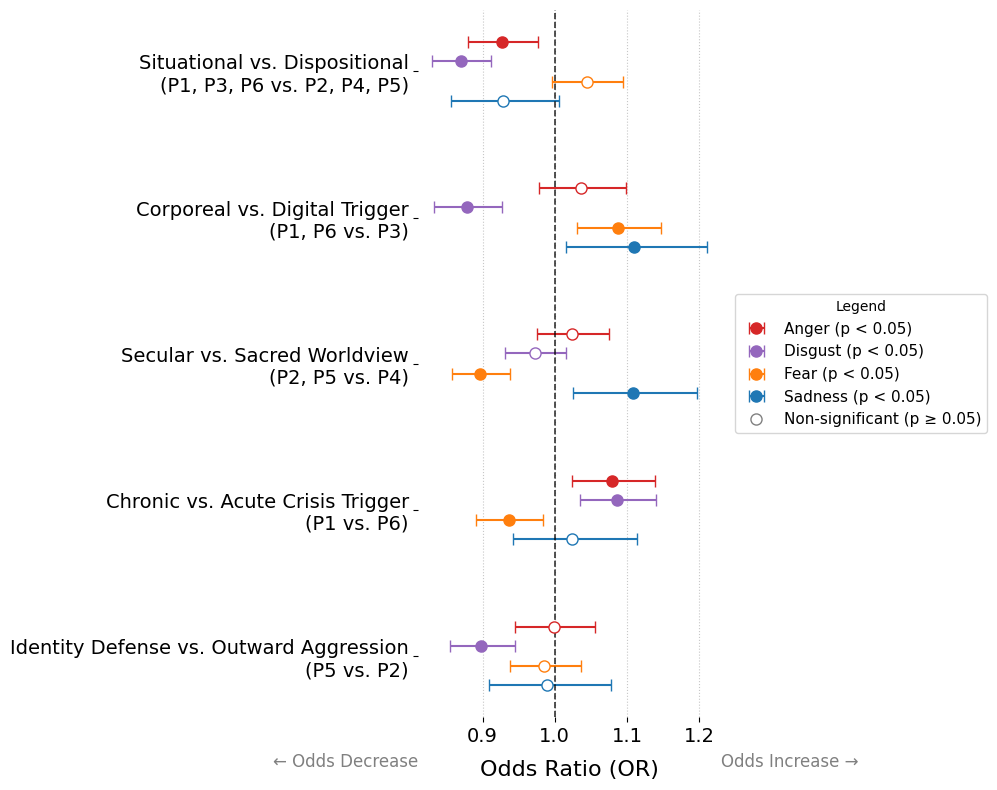

In [ ]:
emotions = ['anger', 'disgust', 'fear', 'sadness']
all_emotion_data = []

base_interpretations = {
    'balance_1': 'Situational vs. Dispositional\n(P1, P3, P6 vs. P2, P4, P5)',
    'balance_2': 'Corporeal vs. Digital Trigger\n(P1, P6 vs. P3)',
    'balance_3': 'Secular vs. Sacred Worldview\n(P2, P5 vs. P4)',
    'balance_4': 'Chronic vs. Acute Crisis Trigger\n(P1 vs. P6)',
    'balance_5': 'Identity Defense vs. Outward Aggression\n(P5 vs. P2)'
}

for emo in emotions:
    model = models_dict[f'ilr_{emo}']
    params = model.params
    conf = model.conf_int()
    pvalues = model.pvalues
    
    temp_df = pd.DataFrame({
        'OR': np.exp(params),
        'lower_ci': np.exp(conf[0]),
        'upper_ci': np.exp(conf[1]),
        'pvalue': pvalues,
        'emotion': emo
    }).reset_index().rename(columns={'index': 'balance'})
    
    all_emotion_data.append(temp_df)

long_df = pd.concat(all_emotion_data)
long_df = long_df[long_df['balance'].str.startswith('balance_')].reset_index(drop=True)
long_df['interpretation'] = long_df['balance'].map(base_interpretations)


color_map = {
    'anger': '#d62728',  # Red
    'disgust': '#9467bd', # Purple
    'fear': '#ff7f0e',   # Orange
    'sadness': '#1f77b4' # Blue
}
y_offsets = {
    'anger': -0.2,
    'disgust': -0.07,
    'fear': 0.07,
    'sadness': 0.2
}

fig, ax = plt.subplots(figsize=(12, 8))
y_labels = list(base_interpretations.values())
y_positions = np.arange(len(y_labels))

for emo in emotions:
    emo_data = long_df[long_df['emotion'] == emo]
    errors = [emo_data['OR'] - emo_data['lower_ci'], 
              emo_data['upper_ci'] - emo_data['OR']]
    
    is_significant = emo_data['pvalue'] < 0.05
    # Use .values to ensure clean numpy boolean indexing
    is_significant_np = is_significant.values 

    # Plot significant points (filled)
    ax.errorbar(
        x=emo_data[is_significant]['OR'], 
        # --- FIX IS HERE ---
        y=y_positions[is_significant_np] + y_offsets[emo],
        xerr=(errors[0][is_significant], errors[1][is_significant]),
        fmt='o', capsize=4, color=color_map[emo], markersize=8, elinewidth=1.5,
        label=f'{emo.capitalize()} (p < 0.05)'
    )
    
    # Plot non-significant points (open)
    ax.errorbar(
        x=emo_data[~is_significant]['OR'], 
        # --- FIX IS HERE ---
        y=y_positions[~is_significant_np] + y_offsets[emo],
        xerr=(errors[0][~is_significant], errors[1][~is_significant]),
        fmt='o', capsize=4, color=color_map[emo], markerfacecolor='white', markersize=8, elinewidth=1.5,
        label='_nolegend_'
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=14)
ax.invert_yaxis()
ax.axvline(x=1, linestyle='--', color='black', linewidth=1.2, alpha=0.8)
#ax.set_title('Unified Effects of Persona Balances on Narrator Emotions', fontsize=18, pad=20)
ax.set_xlabel('Odds Ratio (OR)', fontsize=16, labelpad=10)
ax.set_ylabel('')
ax.grid(axis='x', linestyle=':', alpha=0.7)
sns.despine(left=True, bottom=True)
ax.text(0, -0.05, '← Odds Decrease', transform=ax.transAxes, ha='right', va='top', fontsize=12, color='gray')
ax.text(1.0, -0.05, 'Odds Increase →', transform=ax.transAxes, ha='left', va='top', fontsize=12, color='gray')

handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], marker='o', color='gray', markerfacecolor='white', markersize=8, linestyle='None'))
labels.append('Non-significant (p ≥ 0.05)')

ax.legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11, title='Legend')
ax.tick_params(axis='x', labelsize=14)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Second version:

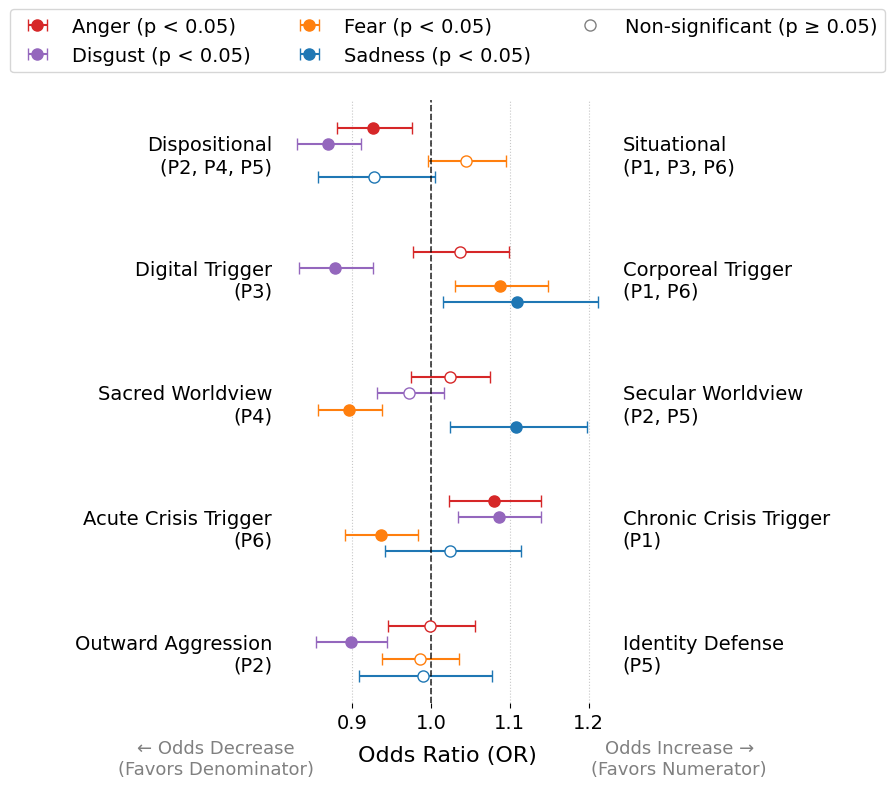

In [ ]:
emotions = ['anger', 'disgust', 'fear', 'sadness']
all_emotion_data = []

# Left side = Denominator group (favored when OR < 1 / Odds Decrease)
left_labels = [
    'Dispositional\n(P2, P4, P5)',
    'Digital Trigger\n(P3)',
    'Sacred Worldview\n(P4)',
    'Acute Crisis Trigger\n(P6)',
    'Outward Aggression\n(P2)'
]

# Right side = Numerator group (favored when OR > 1 / Odds Increase)
right_labels = [
    'Situational\n(P1, P3, P6)',
    'Corporeal Trigger\n(P1, P6)',
    'Secular Worldview\n(P2, P5)',
    'Chronic Crisis Trigger\n(P1)',
    'Identity Defense\n(P5)'
]

for emo in emotions:
    model = models_dict[f'ilr_{emo}']
    params = model.params
    conf = model.conf_int()
    pvalues = model.pvalues
    
    temp_df = pd.DataFrame({
        'OR': np.exp(params),
        'lower_ci': np.exp(conf[0]),
        'upper_ci': np.exp(conf[1]),
        'pvalue': pvalues,
        'emotion': emo
    }).reset_index().rename(columns={'index': 'balance'})
    
    all_emotion_data.append(temp_df)

long_df = pd.concat(all_emotion_data)
long_df = long_df[long_df['balance'].str.startswith('balance_')].reset_index(drop=True)


color_map = {
    'anger': '#d62728',   # Red
    'disgust': '#9467bd', # Purple
    'fear': '#ff7f0e',    # Orange
    'sadness': '#1f77b4'  # Blue
}
y_offsets = {
    'anger': -0.2,
    'disgust': -0.07,
    'fear': 0.07,
    'sadness': 0.2
}

fig, ax = plt.subplots(figsize=(8, 8))
y_positions = np.arange(len(left_labels))

for emo in emotions:
    emo_data = long_df[long_df['emotion'] == emo]
    errors = [emo_data['OR'] - emo_data['lower_ci'], 
              emo_data['upper_ci'] - emo_data['OR']]
    
    is_significant = emo_data['pvalue'] < 0.05
    is_significant_np = is_significant.values 

    # Plot significant points (filled)
    ax.errorbar(
        x=emo_data[is_significant]['OR'], 
        y=y_positions[is_significant_np] + y_offsets[emo],
        xerr=(errors[0][is_significant], errors[1][is_significant]),
        fmt='o', capsize=4, color=color_map[emo], markersize=8, elinewidth=1.5,
        label=f'{emo.capitalize()} (p < 0.05)'
    )
    
    # Plot non-significant points (open)
    ax.errorbar(
        x=emo_data[~is_significant]['OR'], 
        y=y_positions[~is_significant_np] + y_offsets[emo],
        xerr=(errors[0][~is_significant], errors[1][~is_significant]),
        fmt='o', capsize=4, color=color_map[emo], markerfacecolor='white', markersize=8, elinewidth=1.5,
        label='_nolegend_'
    )

# 1. Left Y-Axis (Denominator / Odds Decrease)
ax.set_yticks(y_positions)
ax.set_yticklabels(left_labels, fontsize=15)
ax.invert_yaxis()

# 2. Right Y-Axis (Numerator / Odds Increase)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())  # Sync with ax inversion & bounds
ax2.set_yticks(y_positions)
ax2.set_yticklabels(right_labels, fontsize=15)

# 3. Clean up ticks and spines for both axes
ax.tick_params(left=False, labelsize=14)
ax2.tick_params(right=False, labelsize=14)
for spine in ax.spines.values():
    spine.set_visible(False)
for spine in ax2.spines.values():
    spine.set_visible(False)

# Reference line at OR = 1
ax.axvline(x=1, linestyle='--', color='black', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Odds Ratio (OR)', fontsize=16, labelpad=10)
ax.grid(axis='x', linestyle=':', alpha=0.7)

# Direction indicators aligned with the two sides
ax.text(-0.2, -0.06, '← Odds Decrease\n(Favors Denominator)', transform=ax.transAxes, ha='center', va='top', fontsize=13, color='gray')
ax.text(1.2, -0.06, 'Odds Increase →\n(Favors Numerator)', transform=ax.transAxes, ha='center', va='top', fontsize=13, color='gray')

# Legend placed horizontally on top (avoids overlapping the right labels)
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], marker='o', color='gray', markerfacecolor='white', markersize=8, linestyle='None'))
labels.append('Non-significant (p ≥ 0.05)')

ax.legend(
    handles=handles, 
    labels=labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.03), 
    ncol=3, 
    fontsize=14, 
    frameon=True
)

plt.tight_layout()
plt.savefig("../figs/balances.pdf", bbox_inches="tight", dpi=300)
plt.show()